# **Diseño, simulación y construcción de un filtro Butterworth analógico**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
from scipy import signal
from scipy.fft import fft, fftshift, fftfreq
import scipy.io
import matplotlib.pyplot as plt
pi=np.pi

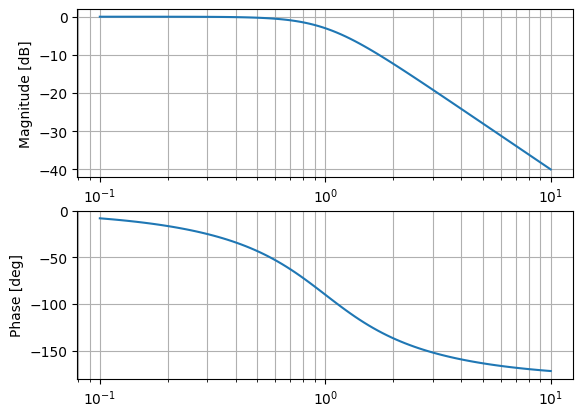

In [ ]:
num = [1]
den = [1, np.sqrt(2), 1]

sys1 = signal.TransferFunction(num, den)

w1, mag1, phase1 = signal.bode(sys1)
plt.subplot(2, 1, 1)
plt.semilogx(w1, mag1)
plt.ylabel('Magnitude [dB]')
plt.grid(which='both')
plt.subplot(2, 1, 2)
plt.semilogx(w1, phase1)
plt.ylabel('Phase [deg]')
plt.grid(which='both')
plt.show()

In [ ]:
# Identificar la magnitud en la frecuencia de corte
frec = np.abs(w1 - 1).argmin() #Calcula la diferencia (distancia) entre cada valor de (w1 - 1) y guarda en frec el indice donde se encuentra la diferencia más pequeña

prom_mag = (mag1[frec] + mag1[frec + 1]) / 2
prom_frec = (w1[frec] + w1[frec + 1]) / 2

print(f"Magnitud en la frecuencia más cercana a la frecuencia de corte: {mag1[frec]:.2f} dB")
print(f"Frecuencia más cercana a la de corte: {w1[frec]:.2f} rad/s")
print(f"Magnitud en la siguiente frecuencia más cercana a la frecuencia de corte: {mag1[frec + 1]:.2f} dB")
print(f"Siguiente frecuencia más cercana a la de corte: {w1[frec + 1]:.2f} rad/s")
print(f"Magnitud promedio: {prom_mag:.2f} dB")
print(f"Frecuencia promedio: {prom_frec:.2f} rad/s")

Magnitud en la frecuencia más cercana a la frecuencia de corte: -2.81 dB
Frecuencia más cercana a la de corte: 0.98 rad/s
Magnitud en la siguiente frecuencia más cercana a la frecuencia de corte: -3.22 dB
Siguiente frecuencia más cercana a la de corte: 1.02 rad/s
Magnitud promedio: -3.01 dB
Frecuencia promedio: 1.00 rad/s


Text(0.5, 1.0, 'Ecuacion del sistema')

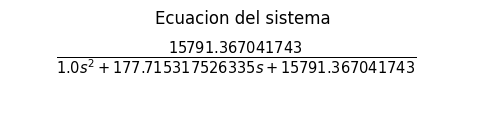

In [ ]:
import sympy as sp
from sympy.printing import latex
s = sp.symbols('s')
num = [(40*pi)**2]
den = [1, 40*pi*np.sqrt(2), (40*pi)**2]
h = sp.Poly(num, s)/sp.Poly(den, s) #De potencias mayores a potencias menores
H1 = signal.TransferFunction(num, den)

from sympy.printing import latex
plt.figure(figsize = (6, 1))
plt.text(0.1, 0.6, f'${latex(h)}$', fontsize = 15)
plt.gca().set_axis_off()
plt.title("Ecuacion del sistema")

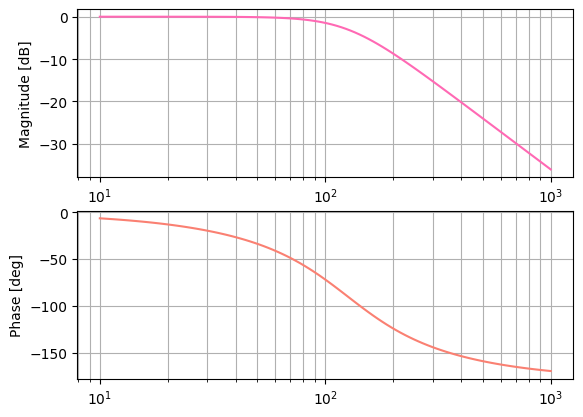

In [ ]:
num = [(40*pi)**2]
den = [1, 40*pi*np.sqrt(2), (40*pi)**2]

sys1 = signal.TransferFunction(num, den)

w1, mag1, phase1 = signal.bode(sys1)
plt.subplot(2, 1, 1)
plt.semilogx(w1, mag1, color = 'hotpink')
plt.ylabel('Magnitude [dB]')
plt.grid(which='both')
plt.subplot(2, 1, 2)
plt.semilogx(w1, phase1, color = '#FA8072')
plt.ylabel('Phase [deg]')
plt.grid(which='both')
plt.show()

In [ ]:
# Identificar la frecuencia donde la magnitud cae -3 dB con respecto al máximo
frec = np.abs(w1 - (40*pi)).argmin() #Calcula la diferencia (distancia) entre cada valor de mag1 y (g_max - 3) (la caída de -3dB para la frec de corte)

# Obtener la frecuencia de corte (en Hz)
fc = mag1[frec]

prom_mag = (mag1[frec] + mag1[frec + 1]) / 2
prom_frec = (w1[frec] + w1[frec + 1]) / 2

# Imprimir resultados
print(f"Magnitud en la frecuencia más cercana a la frecuencia de corte: {mag1[frec]:.2f} dB")
print(f"Frecuencia más cercana a la de corte: {w1[frec]:.2f} rad/s")
print(f"Magnitud en la siguiente frecuencia más cercana a la frecuencia de corte: {mag1[frec + 1]:.2f} dB")
print(f"Siguiente frecuencia más cercana a la de corte: {w1[frec + 1]:.2f} rad/s")
print(f"Magnitud promedio: {prom_mag:.2f} dB")
print(f"Frecuencia promedio: {prom_frec:.2f} rad/s")

Magnitud en la frecuencia más cercana a la frecuencia de corte: -2.85 dB
Frecuencia más cercana a la de corte: 123.28 rad/s
Magnitud en la siguiente frecuencia más cercana a la frecuencia de corte: -3.25 dB
Siguiente frecuencia más cercana a la de corte: 129.15 rad/s
Magnitud promedio: -3.05 dB
Frecuencia promedio: 126.22 rad/s


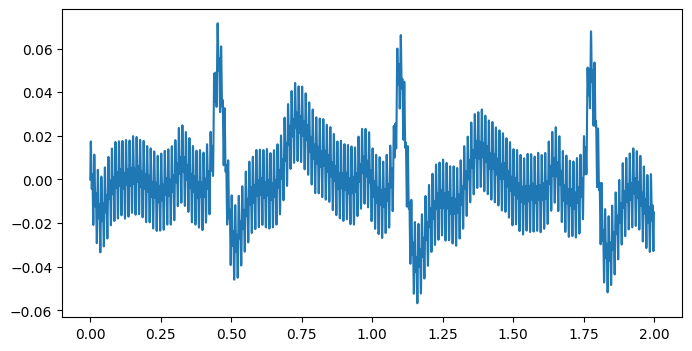

In [ ]:
datos = scipy.io.loadmat('/content/drive/MyDrive/ecg_noisy2.mat')
t = datos['t'][0]
ecg = datos['ecg'][0]
plt.figure(figsize=(8, 4))
plt.plot(t, ecg)

In [ ]:
print (datos)

{'__header__': b'MATLAB 5.0 MAT-file Platform: posix, Created on: Thu Jun 12 23:53:06 2025', '__version__': '1.0', '__globals__': [], 'ecg': array([[ 0.        ,  0.00373921,  0.00729958, ..., -0.02246078,
        -0.01885615, -0.01507218]]), 't': array([[0.00000e+00, 2.50000e-04, 5.00000e-04, ..., 1.99925e+00,
        1.99950e+00, 1.99975e+00]])}


Text(0.5, 1.0, 'Señal de salida')

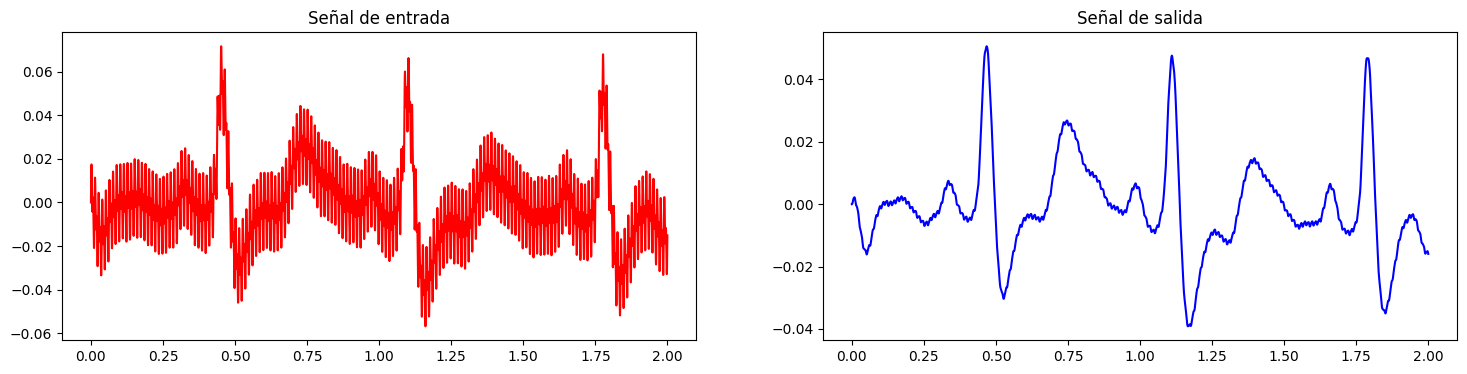

In [ ]:
H = signal.TransferFunction(num, den)
t2 = t + abs(min(t))
n_out, y, _= signal.lsim(H, ecg, t2)
plt.figure(figsize=(18, 4))
plt.subplot(1, 2, 1)
plt.plot(t, ecg, color = 'red')
plt.title("Señal de entrada")

plt.subplot(1, 2, 2)
plt.plot(n_out, y, color = 'blue')
plt.title("Señal de salida")

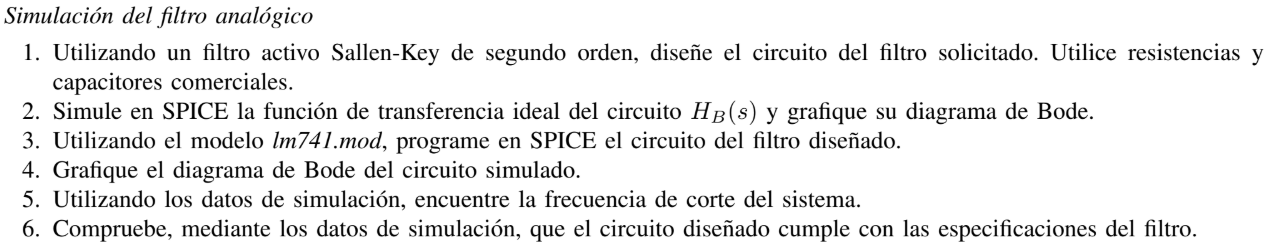

In [ ]:
#Instalación de librerías compatibles con PySpice v1.4.2
!apt install -q /content/drive/MyDrive/PySpice/1.libngspice0.deb
!apt install -q /content/drive/MyDrive/PySpice/2.libngspice0-dev.deb
!apt install -q /content/drive/MyDrive/PySpice/3.ngspice.deb
!apt install -q /content/drive/MyDrive/PySpice/4.tclspice.deb

# Instalación de PySpice v1.4.2
#!pip install PySpice==1.4.2

Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  libncurses5 libtinfo5
The following NEW packages will be installed:
  libncurses5 libngspice0 libtinfo5
0 upgraded, 3 newly installed, 0 to remove and 35 not upgraded.
Need to get 207 kB/2,219 kB of archives.
After this operation, 8,261 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 libtinfo5 amd64 6.3-2ubuntu0.1 [100 kB]
Get:2 /content/drive/.shortcut-targets-by-id/1XaEsfm2G-r3KJ_DdRNCMjf6JbZbR0cUG/PySpice/1.libngspice0.deb libngspice0 amd64 30.2-1~bpo9+1 [2,012 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 libncurses5 amd64 6.3-2ubuntu0.1 [107 kB]
Fetched 207 kB in 1s (362 kB/s)
Selecting previously unselected package libtinfo5:amd64.
(Reading database ... 126319 files and directories currently installed.)
Preparing to unpack .../libtinfo5_6.3-2ubuntu0.1_amd64.d

In [ ]:
#Instalación de PySpice v1.4.2
!pip install -q /content/drive/MyDrive/PySpice/PySpice-1.4.2.tar.gz

  Preparing metadata (setup.py) ... done


In [ ]:
from PySpice.Spice.Netlist import Circuit
from PySpice.Plot.BodeDiagram import bode_diagram
from PySpice.Unit import *

import numpy as np
from scipy import signal
from scipy.fft import fft, fftshift, fftfreq
import matplotlib.pyplot as plt

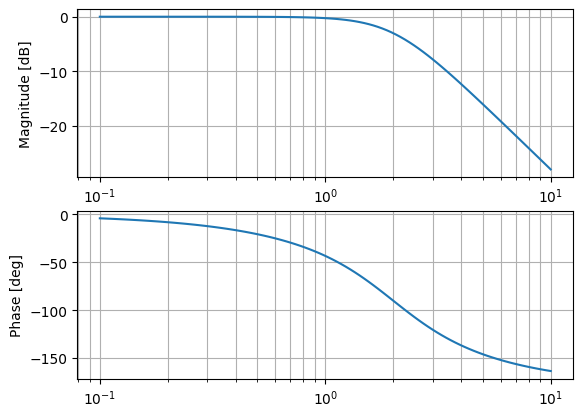

In [ ]:
R1 = 3733.193
R2 = 66966.807
C3 = 0.0001
C4 = 0.00001

num = [1 / (R1 * R2 * C3 * C4)]
den = [1, (1 / C3) * (1 / R1 + 1 / R2), 1/(R1 * R2 * C3 * C4)]

sys1 = signal.TransferFunction(num, den)

w1, mag1, phase1 = signal.bode(sys1)
plt.subplot(2, 1, 1)
plt.semilogx(w1, mag1)
plt.ylabel('Magnitude [dB]')
plt.grid(which='both')
plt.subplot(2, 1, 2)
plt.semilogx(w1, phase1)
plt.ylabel('Phase [deg]')
plt.grid(which='both')
plt.show()

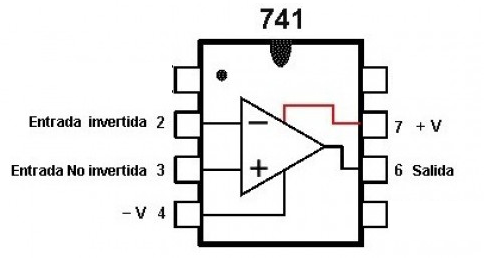

In [ ]:
filtro = Circuit('Amplificador LM741')
filtro.include('/content/drive/MyDrive/PySpice/LM741.mod') #Representa al operacional de manera real

filtro.SinusoidalVoltageSource('in', 1, 0, amplitude=1@u_V)
filtro.V('+',7,0,15@u_V) #Entrada NO inversora
filtro.V('-',0,4,15@u_V) #Entrada inversora
filtro.R('1',1,5,3.733@u_kOhm)
filtro.R('2',5,3,66.966@u_kOhm)
filtro.C('3',5,6,10@u_uF)
filtro.C('4',3,0,1@u_uF)
filtro.X('741','LM741/NS',6,3,7,4,6) #Los nodos en el orden que los pide el fabricante
#inv, no inv, posit, neg, salida
#el .X indica que va a incluir lo del archivo subido:
"""
Nombre del archivo, ya está en el documento
Nodos en orden como lo indica el diagrama del doc
"""

print(filtro)

.title Amplificador LM741
.include /content/drive/.shortcut-targets-by-id/1XaEsfm2G-r3KJ_DdRNCMjf6JbZbR0cUG/PySpice/LM741.mod
Vin 1 0 DC 0V AC 1V SIN(0V 1V 50Hz 0s 0Hz)
V+ 7 0 15V
V- 0 4 15V
R1 1 5 3.733kOhm
R2 5 3 66.966kOhm
C3 5 6 10uF
C4 3 0 1uF
X741 6 3 7 4 6 LM741/NS



In [ ]:
simu = filtro.simulator(temperature=25, nominal_temperature=25)
data = simu.ac(start_frequency=0.1@u_Hz, stop_frequency=100@u_Hz,number_of_points=100, variation='dec')

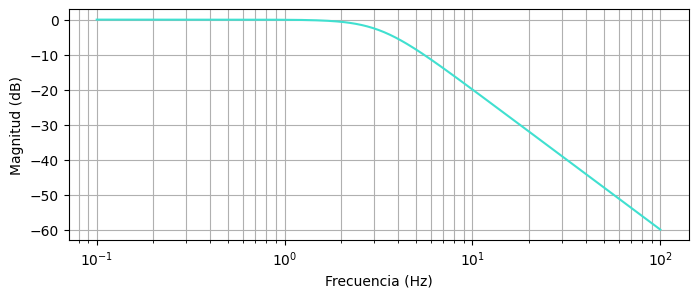

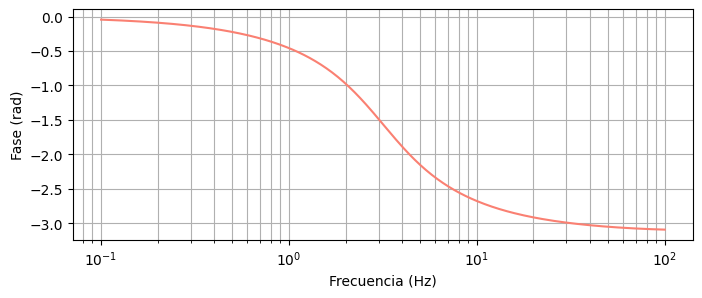

In [ ]:
#Diagrama de Bode
omega = data.frequency
mag = 20*np.log10(np.absolute(np.array(data.nodes['6'])))
phase = np.angle(np.array(data.nodes['6']))

plt.figure(figsize=(8,3))
plt.semilogx(omega, mag, color = '#40E0D0') #Indica el nodo de salida, nodo 6
plt.grid(which="both")
plt.ylabel('Magnitud (dB)');
plt.xlabel('Frecuencia (Hz)');


plt.figure(figsize=(8,3))
plt.semilogx(omega, phase, color = '#FA8072')
plt.grid(which="both")
plt.ylabel('Fase (rad)');
plt.xlabel('Frecuencia (Hz)');

In [ ]:
omega_Hz = np.array(omega)

frec = abs(omega_Hz - 20).argmin()

# Get the magnitude at that frequency
magnitud_en_fc = 20*np.log10(np.absolute(np.array(data.nodes['6'])))[frec]

prom_mag = (magnitud_en_fc + 20*np.log10(np.absolute(np.array(data.nodes['6'])))[frec + 1]) / 2
prom_frec = (omega_Hz[frec] + omega_Hz[frec + 1]) / 2

# Print the result
print(f"Magnitud en la frecuencia más cercana a la frecuencia de corte: {magnitud_en_fc:.2f} dB")
print(f"Frecuencia más cercana a la de corte: {omega_Hz[frec]:.2f} rad/s")
print(f"Magnitud en la siguiente frecuencia más cercana a la frecuencia de corte: {20*np.log10(np.absolute(np.array(data.nodes['6'])))[frec + 1]:.2f} dB")
print(f"Siguiente frecuencia más cercana a la de corte: {omega_Hz[frec + 1]:.2f} rad/s")
print(f"Magnitud promedio: {prom_mag:.2f} dB")
print(f"Frecuencia promedio: {prom_frec:.2f} rad/s")

Magnitud en la frecuencia más cercana a la frecuencia de corte: -31.89 dB
Frecuencia más cercana a la de corte: 19.95 rad/s
Magnitud en la siguiente frecuencia más cercana a la frecuencia de corte: -32.29 dB
Siguiente frecuencia más cercana a la de corte: 20.42 rad/s
Magnitud promedio: -32.09 dB
Frecuencia promedio: 20.19 rad/s
